# EMA monitoring in a real mini-batch fit

This notebook fits a normal location model with mini-batch optimization and uses Liesel's integrated loss plot to show the continuous EMA monitor.

In [1]:
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

The data contain 256 observations and each epoch contains 32 mini-batches. With `effective_window=5.0`, the EMA span is 160 batch steps and its half-life is roughly 1.7 epoch equivalents. The span is not a hard inclusion window: older losses retain exponentially decreasing weight.

In [2]:
true_loc = 1.5
y_values = true_loc + jax.random.normal(jax.random.key(1), (256,))
loc = lsl.Var.new_param(jnp.array(0.0), name="loc")
y = lsl.Var.new_obs(
    y_values,
    lsl.Dist(tfd.Normal, loc=loc, scale=1.0),
    name="y",
)
model = lsl.Model([y])
monitor = opt.EmaTrainLossMonitor(effective_window=5.0)
optimizer = opt.Optimizer(["loc"], optax.adam(learning_rate=2e-3))
engine = opt.LieselOptim(
    model,
    loss_monitor=monitor,
    batch_size=8,
    optimizers=[optimizer],
    stopper=opt.Stopper(epochs=50, patience=50),
    seed=2,
    show_progress=False,
).build_engine()
result = engine.fit()

`Training (epoch mean)` gives equal weight to all 32 post-update batch losses evaluated at the successive parameter positions visited during an epoch. It is not a complete training loss evaluated at the final epoch position. `Monitoring (training EMA)` is the continuous, bias-corrected EMA sampled at each epoch end. It may look less smooth than the epoch mean because it deliberately gives recent batches more weight, and it does not reset at epoch boundaries. The vertical line marks the smallest recorded monitoring loss; for EMA monitoring, `result.position` still selects the final position.

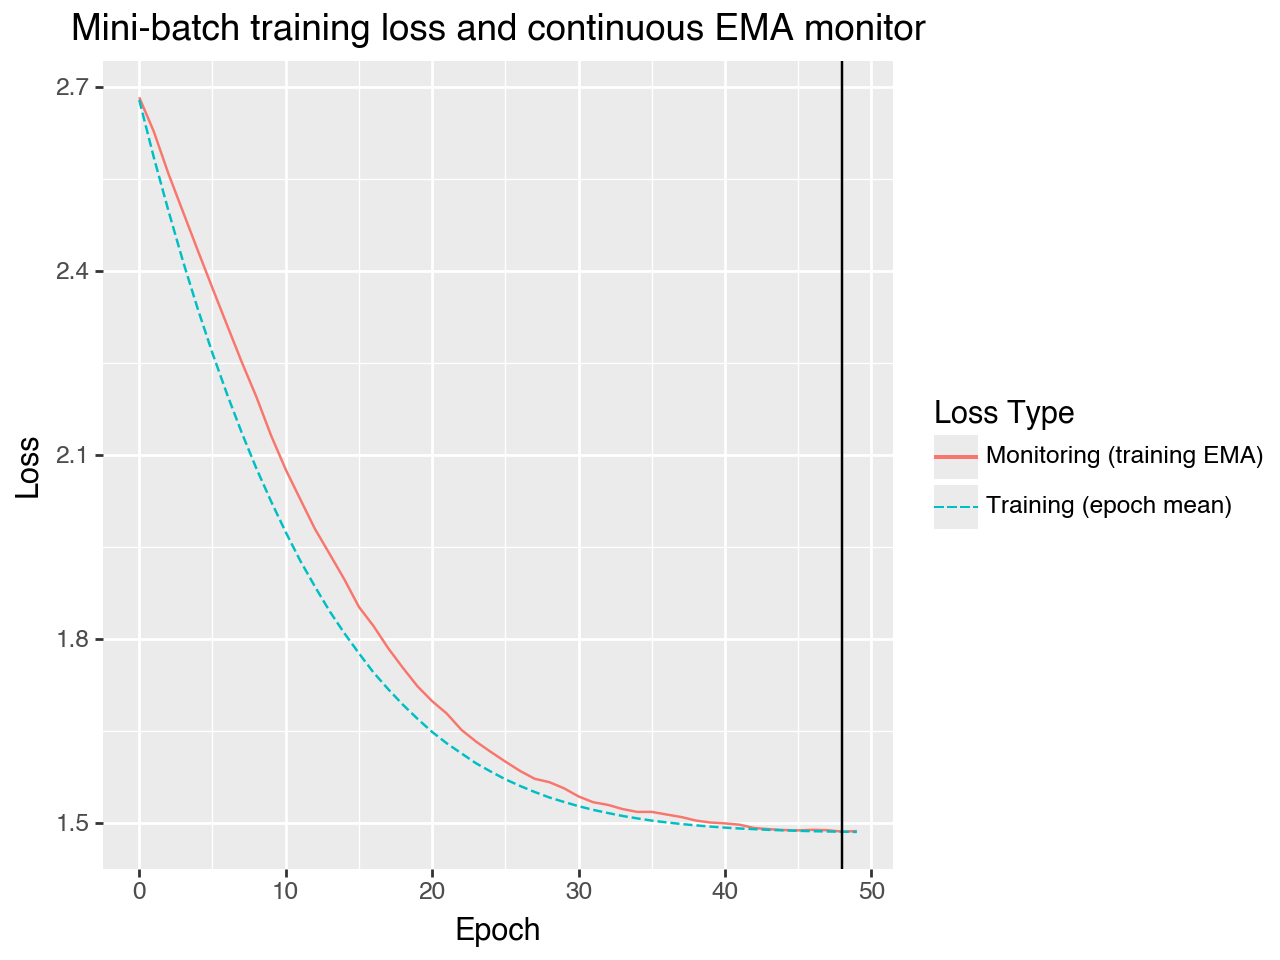

In [3]:
result.plot_loss(title="Mini-batch training loss and continuous EMA monitor")